In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
import operator
from dotenv import load_dotenv

load_dotenv()
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')
model_pro = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [2]:
class aistate(TypedDict):
    topic : str
    topic_summary : str
    keyword : str
    heading : str 
    pointer : str
    blog : str
    individual_scores: Annotated[list[int], operator.add] 
    keyword_feedback : str
    newness_feedback : str
    language_feedback : str
    final_score : float
    final_feedback : str
    iteration : int
    max_iteration : int
    # status : Literal['Pass','Fail']


# For structure output:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description='Detailed feedback for the essay')
    score: int = Field(description='Score out of 10', ge=0, le=10)
    content : str = Field(description='content should be in pointer and each new topic seperate by "-----"')

structured_model = model.with_structured_output(EvaluationSchema)



def topic_summary_search(state : aistate):
    prompt =  f"write a 2-3 line summary which describe the topic: \n {state["topic"]}."
    
    aa = model.invoke(prompt).content
    
    return {'topic_summary': aa}

def keyword_search(state : aistate):
    prompt =  f"Search suitable keyword for summary: \n {state["topic_summary"]}."
    
    aa = model.invoke(prompt).content
    
    return {'keyword': aa}

def heading_search(state : aistate):
    prompt =  f"Search suitable heading for summary: \n {state["topic_summary"]}."
    
    aa = model.invoke(prompt).content
    
    return {'heading': aa}

def pointer_search(state : aistate):
    prompt =  f"Write 10 pointer for summary: \n {state["topic_summary"]}."
    
    aa = model.invoke(prompt).content
    
    return {'pointer': aa}

def blog_write(state : aistate):
    prompt =  f"""Write a 200 words blog using below details:
            keywords : {state['keyword']} \n
            heading : {state['heading']}  \n
            pointer : {state['pointer']}  \n
            """      
    aa = model.invoke(prompt).content
    
    return {'blog': aa }

def optimizer(state : aistate):
    if state['iteration'] == 1:
        aa = state['blog']
    else:   
        prompt =  f"""Write a 200 words blog using below details:
            keywords : {state['keyword']} \n
            heading : {state['heading']}  \n
            pointer : {state['pointer']}  \n
            feedback : {state['final_feedback']} \n
        """  
        aa = model_pro.invoke(prompt).content
        
    bb = state['iteration'] + 1
    
    return {'blog': aa , 'iteration': bb }
    

def keyword_eval(state : aistate):
    prompt = f'Evaluate the keyeord quality of the following blog and provide a feedback and assign a score out of 10 \n {state["blog"]}'
    output = structured_model.invoke(prompt)

    return {'keyword_feedback': output.feedback, 'individual_scores': [output.score]}

def newness_eval(state : aistate):
    prompt = f'Evaluate the newness of the following blog and provide a feedback and assign a score out of 10 \n {state["blog"]}'
    output = structured_model.invoke(prompt)

    return {'newness_feedback': output.feedback, 'individual_scores': [output.score]}

def language_eval(state : aistate):
    prompt = f'Evaluate the language of the following blog and provide a feedback and assign a score out of 10 \n {state["blog"]}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

# Final note function
def final_eval(state : aistate):

    # summary feedback
    prompt = f'Based on the following feedbacks create a short summarized feedback \n Blog language feedback - {state["language_feedback"]} \n Blog newness feedback - {state["newness_feedback"]} \n top keyword in the blog feedback - {state["keyword_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'final_feedback': overall_feedback , 'final_score': avg_score }
    

def check_score(state : aistate):
    if state['final_score'] > 8 or state['iteration'] >= state['max_iteration']:
        return "Pass"
    else:
        return "Optimize"


    
    

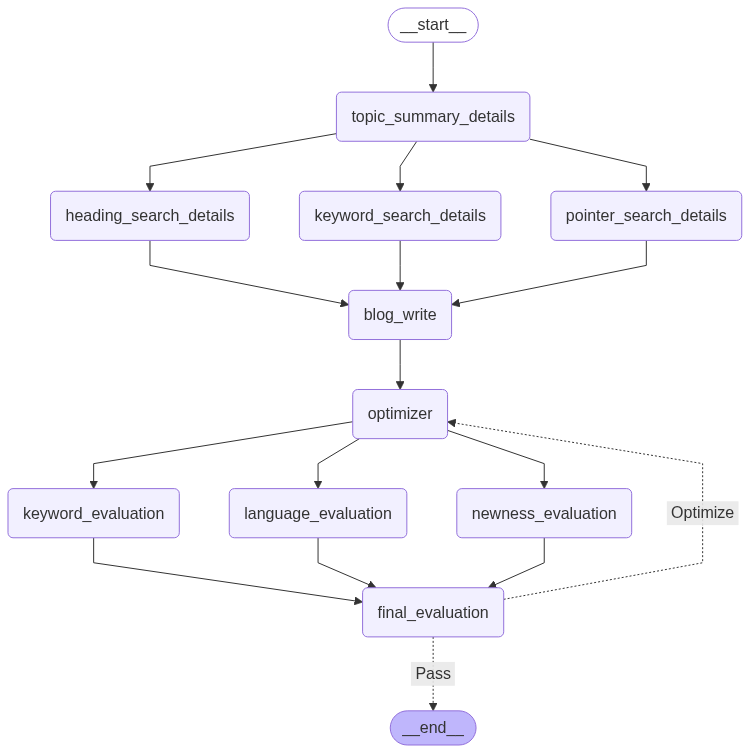

In [3]:
graph = StateGraph(aistate)

graph.add_node('topic_summary_details',topic_summary_search)
graph.add_node('keyword_search_details',keyword_search)
graph.add_node('heading_search_details',heading_search)
graph.add_node('pointer_search_details',pointer_search)
graph.add_node('blog_write',blog_write)
graph.add_node('keyword_evaluation',keyword_eval)
graph.add_node('newness_evaluation',newness_eval)
graph.add_node('language_evaluation',language_eval)
graph.add_node('final_evaluation',final_eval)
graph.add_node('optimizer',optimizer)

graph.add_edge(START,'topic_summary_details')
graph.add_edge('topic_summary_details','keyword_search_details')
graph.add_edge('topic_summary_details','heading_search_details')
graph.add_edge('topic_summary_details','pointer_search_details')
graph.add_edge('keyword_search_details','blog_write')
graph.add_edge('heading_search_details','blog_write')
graph.add_edge('pointer_search_details','blog_write')
graph.add_edge('blog_write','optimizer')
graph.add_edge('optimizer', 'keyword_evaluation')
graph.add_edge('optimizer', 'newness_evaluation')
graph.add_edge('optimizer', 'language_evaluation')
graph.add_edge('keyword_evaluation','final_evaluation')
graph.add_edge('newness_evaluation','final_evaluation')
graph.add_edge('language_evaluation','final_evaluation')
graph.add_conditional_edges('final_evaluation',check_score, {'Pass': END , 'Optimize' : 'optimizer'})



workflow = graph.compile()
workflow

In [ ]:
initial = {'topic': input(), 'iteration' : 1, 'max_iteration': 5}
workflow.invoke(initial)

# prompt = f"white a 2-3 line summary which describe the topic:  {input()} \n "

# response = model.invoke(prompt).content

# response